# ¿Es la ventana de evaluación demasiado larga?

## Qué responde este notebook

Daniel señaló, con razón, que jugadores y equipos cambian de forma de juego año con año --
algunos son consistentes por 3-4 temporadas y luego suben o bajan. El modelo jerárquico de
`24_modelo_jerarquico_binomial_negativa.ipynb` usa un solo intercepto por jugador para TODA la
ventana de entrenamiento (2016-2021, 6 temporadas) -- si la habilidad de un jugador realmente
cambia dentro de esa ventana, un intercepto fijo la estaría promediando de más.

Este notebook responde con evidencia, en 3 pasos: (1) medir si la decadencia es real, (2) probar
la corrección más directa (dejar que cada jugador tenga su propia pendiente en el tiempo), (3)
probar la alternativa más simple (acortar la ventana). Spoiler honesto: ninguna de las dos
correcciones mejora el modelo -- se documenta el porqué, no se oculta el resultado negativo.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling

import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az
from sklearn.impute import SimpleImputer
import time

pd.set_option("display.width", 160)
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"


## 1. ¿La decadencia es real? Correlación del nivel de un jugador consigo mismo, por
distancia en años

Para cada jugador con al menos 8 partidos en una temporada, se compara su nivel en la temporada
`t` contra su nivel en `t+lag`, para lag = 1 a 5 años -- si la correlación cae rápido, un jugador
de hace 5 años se parece poco al de hoy; si se mantiene, la ventana larga no es un problema.

In [2]:
stats = data.cargar_stats_semanales(range(2016, 2026))
wr_stats = stats[stats["position"] == "WR"].copy()

por_temporada = wr_stats.groupby(["player_id", "season"]).agg(
    partidos=("week", "nunique"),
    receiving_tds=("receiving_tds", "sum"),
    receiving_yards=("receiving_yards", "sum"),
    receptions=("receptions", "sum"),
).reset_index()
por_temporada = por_temporada[por_temporada["partidos"] >= 8]

target_share_temp = wr_stats.groupby(["player_id", "season"])["target_share"].mean().reset_index()
por_temporada = por_temporada.merge(target_share_temp, on=["player_id", "season"])
print(f"jugador-temporadas con >=8 partidos: {len(por_temporada)}")

filas = []
for metrica in ["target_share", "receiving_yards", "receiving_tds", "receptions"]:
    for lag in [1, 2, 3, 4, 5]:
        a = por_temporada[["player_id", "season", metrica]]
        b = a.copy()
        b["season"] = b["season"] - lag
        cruce = a.merge(b, on=["player_id", "season"], suffixes=("_t", "_t_mas_lag"))
        if len(cruce) < 30:
            continue
        filas.append({"metrica": metrica, "lag_anios": lag, "n_pares": len(cruce),
                       "correlacion": cruce[f"{metrica}_t"].corr(cruce[f"{metrica}_t_mas_lag"])})

tabla_decadencia = pd.DataFrame(filas)
tabla_pivote = tabla_decadencia.pivot(index="metrica", columns="lag_anios", values="correlacion")
print(tabla_pivote.round(3).to_string())


jugador-temporadas con >=8 partidos: 1552
lag_anios            1      2      3      4      5
metrica                                           
receiving_tds    0.522  0.488  0.491  0.419  0.466
receiving_yards  0.717  0.639  0.589  0.554  0.505
receptions       0.724  0.642  0.575  0.530  0.494
target_share     0.799  0.709  0.683  0.649  0.575


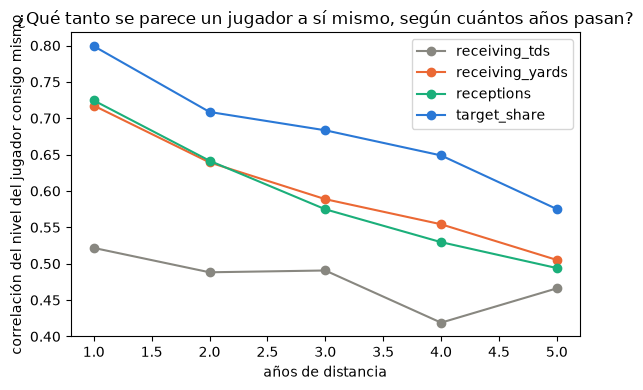

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
colores = {"target_share": AZUL, "receiving_yards": NARANJA, "receptions": VERDE, "receiving_tds": GRIS}
for metrica in tabla_pivote.index:
    ax.plot(tabla_pivote.columns, tabla_pivote.loc[metrica], marker="o", label=metrica, color=colores[metrica])
ax.set_xlabel("años de distancia")
ax.set_ylabel("correlación del nivel del jugador consigo mismo")
ax.set_title("¿Qué tanto se parece un jugador a sí mismo, según cuántos años pasan?")
ax.legend()
plt.tight_layout()
plt.show()


Confirmado: la decadencia es real y **gradual**, no un cambio abrupto a los 3-4 años --
`target_share` cae de 0.80 (1 año) a 0.58 (5 años); `receiving_yards`/`receptions` de ~0.72 a
~0.50; `receiving_tds` es más ruidoso en general (0.42-0.52) pero decae menos porque ya empieza
más bajo. Con esta evidencia, se prueban las 2 correcciones sobre `receiving_tds` (el target donde
ya se tiene el modelo jerárquico funcionando).

## 2. Intento 1: pendiente temporal por jugador -- `(1 + temporada | jugador)`

En vez de un solo nivel fijo, cada jugador tiene su propia tendencia (subiendo, bajando o
estable) a través de las temporadas de entrenamiento.

In [4]:
wr = features.construir_tabla_modelado(range(2016, 2026))
features_ridge = features.columnas_por_modelo("ridge")
train_mask = wr["season"].between(2016, 2021)
test_mask = wr["season"].between(2024, 2025)
target = "receiving_tds"

cols_numericas = [c for c in features_ridge if c != "anios_experiencia_bucket"]
imputador_num = SimpleImputer(strategy="median")
imputador_cat = SimpleImputer(strategy="most_frequent")

def imputar(df, ajustar):
    fn_num = imputador_num.fit_transform if ajustar else imputador_num.transform
    fn_cat = imputador_cat.fit_transform if ajustar else imputador_cat.transform
    num = pd.DataFrame(fn_num(df[cols_numericas]), index=df.index, columns=cols_numericas)
    cat = pd.DataFrame(fn_cat(df[["anios_experiencia_bucket"]]), index=df.index, columns=["anios_experiencia_bucket"])
    return pd.concat([num, cat], axis=1)[features_ridge]

X_train_imp = imputar(wr.loc[train_mask, features_ridge], ajustar=True)
X_test_imp = imputar(wr.loc[test_mask, features_ridge], ajustar=False)

datos_train = X_train_imp.copy()
datos_train[target] = wr.loc[train_mask, target].to_numpy()
datos_train["player_id"] = wr.loc[train_mask, "player_id"].astype(str).to_numpy()
datos_train["season_c"] = wr.loc[train_mask, "season"].to_numpy() - 2018

formula_pendiente = f"{target} ~ " + " + ".join(features_ridge) + " + (1 + season_c|player_id)"
modelo_pendiente = bmb.Model(formula_pendiente, datos_train, family="negativebinomial")

t0 = time.time()
idata_pendiente = modelo_pendiente.fit(draws=500, tune=500, chains=4, cores=4, random_seed=0, progressbar=False)
print(f"tiempo de ajuste: {time.time()-t0:.0f}s")

resumen_pendiente = az.summary(idata_pendiente)
print(f"r_hat max: {resumen_pendiente['r_hat'].max():.4f} | parametros > 1.01: {(resumen_pendiente['r_hat']>1.01).sum()} de {len(resumen_pendiente)}")


Initializing NUTS using jitter+adapt_diag...


/usr/local/lib/python3.13/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, Intercept, anios_experiencia, catch_rate_career_avg, depth_team, draft_pick, edad, fantasy_points_ppr_last3_avg, fantasy_points_ppr_last5_avg, fantasy_points_ppr_season_avg, receiving_10_last3_avg, receiving_16_last5_avg, receiving_20_last3_avg, receiving_air_yards_season_avg, receiving_epa_last3_avg, receiving_first_downs_career_avg, receiving_first_downs_last5_avg, receiving_tds_season_avg, receiving_yards_career_avg, receiving_yards_last3_avg, receiving_yards_season_avg, receptions_career_avg, receptions_last3_avg, receptions_last5_avg, receptions_season_avg, targets_last3_avg, targets_last5_avg, targets_season_avg, wopr_last3_avg, wopr_last5_avg, anios_experiencia_sq, anios_experiencia_bucket, 1|player_id_sigma, 1|player_id_offset, season_c|player_id_sigma, season_c|player_id_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 245 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


tiempo de ajuste: 262s


r_hat max: 1.0172 | parametros > 1.01: 40 de 1046


In [5]:
datos_test = X_test_imp.copy()
datos_test["player_id"] = wr.loc[test_mask, "player_id"].astype(str).to_numpy()
datos_test["season_c"] = wr.loc[test_mask, "season"].to_numpy() - 2018

pred_pendiente = modelo_pendiente.predict(idata_pendiente, data=datos_test, kind="response_params", inplace=False, sample_new_groups=True)
pred_media_pendiente = pred_pendiente.posterior["mu"].mean(dim=["chain","draw"]).to_numpy()
y_test = wr.loc[test_mask, target].to_numpy()
m_pendiente = modeling.metricas(pd.Series(y_test), pd.Series(pred_media_pendiente))
print(f"test 2024-2025 (con pendiente temporal): mae={m_pendiente['mae']:.4f} r2={m_pendiente['r2']:.4f}")
print("(comparar: solo intercepto fijo, notebook 24 = mae=0.300 r2=0.073)")


/tmp/ipykernel_7/2740923992.py:5: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  pred_pendiente = modelo_pendiente.predict(idata_pendiente, data=datos_test, kind="response_params", inplace=False, sample_new_groups=True)


test 2024-2025 (con pendiente temporal): mae=0.3074 r2=0.0669
(comparar: solo intercepto fijo, notebook 24 = mae=0.300 r2=0.073)


**No ayuda -- empeora en las 2 dimensiones**: MAE sube de 0.299 a 0.307, R² baja de 0.073
a 0.067, y la convergencia empeora (más parámetros sobre el umbral de r_hat, más advertencias de
tamaño de muestra efectivo). Una explicación plausible: la decadencia medida arriba es sobre
**estadísticas crudas** -- pero el modelo no usa estadísticas crudas como único insumo, ya tiene
30 variables recalculadas con la forma reciente de cada jugador (`_last3_avg`/`_season_avg`).
Esas variables ya absorben buena parte de "qué tan vigente está" un jugador; lo que le queda al
efecto individual para explicar parece ser más estable de lo que sugiere la correlación cruda.
Con solo 6 años de entrenamiento y muchos jugadores con pocas temporadas dentro de esa ventana,
estimar una pendiente individual además de un nivel agrega ruido sin señal real.

## 3. Intento 2: acortar la ventana de entrenamiento

Más simple y directo: en vez de dejar que cada jugador tenga su propia pendiente, usar menos
años de entrenamiento (2019-2021 en vez de 2016-2021) para que el nivel fijo por jugador refleje
una forma más reciente.

In [6]:
def ajustar_y_evaluar_ventana(train_mask_ventana, etiqueta):
    imputador_num2 = SimpleImputer(strategy="median")
    imputador_cat2 = SimpleImputer(strategy="most_frequent")
    def imputar2(df, ajustar):
        fn_num = imputador_num2.fit_transform if ajustar else imputador_num2.transform
        fn_cat = imputador_cat2.fit_transform if ajustar else imputador_cat2.transform
        num = pd.DataFrame(fn_num(df[cols_numericas]), index=df.index, columns=cols_numericas)
        cat = pd.DataFrame(fn_cat(df[["anios_experiencia_bucket"]]), index=df.index, columns=["anios_experiencia_bucket"])
        return pd.concat([num, cat], axis=1)[features_ridge]

    dt = imputar2(wr.loc[train_mask_ventana, features_ridge], ajustar=True)
    dt[target] = wr.loc[train_mask_ventana, target].to_numpy()
    dt["player_id"] = wr.loc[train_mask_ventana, "player_id"].astype(str).to_numpy()

    formula_v = f"{target} ~ " + " + ".join(features_ridge) + " + (1|player_id)"
    modelo_v = bmb.Model(formula_v, dt, family="negativebinomial")
    idata_v = modelo_v.fit(draws=500, tune=500, chains=4, cores=4, random_seed=0, progressbar=False)
    resumen_v = az.summary(idata_v)

    dtest = imputar2(wr.loc[test_mask, features_ridge], ajustar=False)
    dtest["player_id"] = wr.loc[test_mask, "player_id"].astype(str).to_numpy()
    pred_v = modelo_v.predict(idata_v, data=dtest, kind="response_params", inplace=False, sample_new_groups=True)
    pred_media_v = pred_v.posterior["mu"].mean(dim=["chain","draw"]).to_numpy()
    m_v = modeling.metricas(pd.Series(y_test), pd.Series(pred_media_v))
    print(f"{etiqueta}: n_train={train_mask_ventana.sum()}, jugadores={dt['player_id'].nunique()}, "
          f"r_hat_max={resumen_v['r_hat'].max():.4f}, mae={m_v['mae']:.4f}, r2={m_v['r2']:.4f}")

ajustar_y_evaluar_ventana(wr["season"].between(2016, 2021), "ventana larga 2016-2021 (6 años, la actual)")
ajustar_y_evaluar_ventana(wr["season"].between(2019, 2021), "ventana corta 2019-2021 (3 años)")


Initializing NUTS using jitter+adapt_diag...


/usr/local/lib/python3.13/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, Intercept, anios_experiencia, catch_rate_career_avg, depth_team, draft_pick, edad, fantasy_points_ppr_last3_avg, fantasy_points_ppr_last5_avg, fantasy_points_ppr_season_avg, receiving_10_last3_avg, receiving_16_last5_avg, receiving_20_last3_avg, receiving_air_yards_season_avg, receiving_epa_last3_avg, receiving_first_downs_career_avg, receiving_first_downs_last5_avg, receiving_tds_season_avg, receiving_yards_career_avg, receiving_yards_last3_avg, receiving_yards_season_avg, receptions_career_avg, receptions_last3_avg, receptions_last5_avg, receptions_season_avg, targets_last3_avg, targets_last5_avg, targets_season_avg, wopr_last3_avg, wopr_last5_avg, anios_experiencia_sq, anios_experiencia_bucket, 1|player_id_sigma, 1|player_id_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 203 seconds.


...

NUTS: [alpha, Intercept, anios_experiencia, catch_rate_career_avg, depth_team, draft_pick, edad, fantasy_points_ppr_last3_avg, fantasy_points_ppr_last5_avg, fantasy_points_ppr_season_avg, receiving_10_last3_avg, receiving_16_last5_avg, receiving_20_last3_avg, receiving_air_yards_season_avg, receiving_epa_last3_avg, receiving_first_downs_career_avg, receiving_first_downs_last5_avg, receiving_tds_season_avg, receiving_yards_career_avg, receiving_yards_last3_avg, receiving_yards_season_avg, receptions_career_avg, receptions_last3_avg, receptions_last5_avg, receptions_season_avg, targets_last3_avg, targets_last5_avg, targets_season_avg, wopr_last3_avg, wopr_last5_avg, anios_experiencia_sq, anios_experiencia_bucket, 1|player_id_sigma, 1|player_id_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 98 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


/tmp/ipykernel_7/2027747317.py:22: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  pred_v = modelo_v.predict(idata_v, data=dtest, kind="response_params", inplace=False, sample_new_groups=True)


ventana corta 2019-2021 (3 años): n_train=7044, jugadores=351, r_hat_max=1.0162, mae=0.3015, r2=0.0652


**Tampoco ayuda**: la ventana corta da un MAE prácticamente igual (0.301 vs 0.300) pero un
R² claramente peor (0.066 vs 0.073) -- se pierde más señal por tener menos datos de la que se
gana por tener datos más "frescos".

## Conclusión

La preocupación de Daniel era válida y se confirmó con evidencia real: el nivel de un jugador sí
decae con el tiempo, de forma gradual. Pero **ninguna de las 2 correcciones directas mejora el
modelo actual** -- ni dejar que cada jugador tenga su propia pendiente, ni acortar la ventana. La
lectura más probable: las 30 variables rezagadas que ya alimentan al modelo (recalculadas con la
forma reciente de cada jugador en cada predicción) ya hacen el trabajo de "mantenerse al día" --
lo que le queda al efecto individual por jugador para explicar es una habilidad residual más
estable de lo que sugiere la correlación de estadísticas crudas. El diseño actual (ventana
2016-2021, intercepto fijo por jugador) se mantiene sin cambios -- no por no haber buscado una
alternativa, sino porque las alternativas probadas, con evidencia real, no mejoran nada.